<h2>Modelling: Future Price Direction 2 (XGBoost)

In [3]:
# Load pre split data:
from project_paths import PRE_SPLIT_DATA_LR_PATH
import pandas as pd
print(PRE_SPLIT_DATA_LR_PATH)

data = pd.read_pickle(PRE_SPLIT_DATA_LR_PATH) #Contains Direction_1
nd_data = data.copy()
nd_data = nd_data.drop(columns=["Direction_1"])
nd_data.head()

C:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\data\processed\direction\lr\ind_data.pkl


Price,Close,High,Low,Open,Volume,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist
33,382.845001,390.084015,378.252014,389.230988,16419000,389.398568,385.053349,11.832001,11.397491,36.470417,-3.112802,-7.666231,4.553430
34,386.475006,392.645996,380.834015,382.420990,14188900,387.342141,385.408763,11.811981,11.828239,38.000530,-2.514616,-6.635908,4.121292
35,383.157990,388.575989,382.248993,386.118011,11641300,385.682853,384.846070,6.326996,9.363243,37.120720,-2.281901,-5.765107,3.483206
36,358.416992,385.048004,356.446991,382.962006,26456900,382.234423,378.238800,28.601013,14.642998,31.299762,-4.047210,-5.421527,1.374317
37,358.345001,364.345001,353.304993,358.591003,15585700,378.603995,373.265351,11.040009,14.445000,31.284389,-5.389908,-5.415203,0.025295


In [2]:
from bta_direction_functions import add_direction

XGBoost generally has better performance than LR. Let's see if it can classify time frames shorter than 20 days:

In [9]:
# Direction_1 (1 day)
data_1 = data.copy()
data_1 = data_1.dropna().copy()
X_1 = data_1.drop(columns=['Direction_1'])
y_1 = data_1['Direction_1']
print(X_1.shape, y_1.shape)

# Direction_5 (1 week)
data_5 = nd_data.copy()
data_5 = add_direction(data=data_5,shift=5)
data_5 = data_5.dropna().copy()
X_5 = data_5.drop(columns=['Direction_5'])
y_5 = data_5['Direction_5']
print(X_5.shape, y_5.shape)

# Direction_10 (2 week)
data_10 = nd_data.copy()
data_10 = add_direction(data=data_10,shift=10)
data_10 = data_10.dropna().copy()
X_10 = data_10.drop(columns=['Direction_10'])
y_10 = data_10['Direction_10']
print(X_10.shape, y_10.shape)

# Direction_20 (1 month)
data_20 = nd_data.copy()
data_20 = add_direction(data=data_20,shift=20)
data_20 = data_20.dropna().copy()
X_20 = data_20.drop(columns=['Direction_20'])
y_20 = data_20['Direction_20']
print(X_20.shape, y_20.shape)

(4365, 13) (4365,)
(4360, 13) (4360,)
(4355, 13) (4355,)
(4345, 13) (4345,)


In [10]:
from sklearn.model_selection import train_test_split

# Make sure to pass 'shuffle = False' to the function as we are dealing with temporal data:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.15, shuffle=False)
X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X_5, y_5, test_size=0.15, shuffle=False)
X_train_10, X_test_10, y_train_10, y_test_10 = train_test_split(X_10, y_10, test_size=0.15, shuffle=False)
X_train_20, X_test_20, y_train_20, y_test_20 = train_test_split(X_20, y_20, test_size=0.15, shuffle=False)

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

I think it would be good to have the capability of accurately predicting short term direction. LR clearly wasn't able to do this well. Let's see if XGBoost can:

*Direction_1 (XGBoost, Base)*

{'preprocessor': ColumnTransformer(transformers=[('numeric', 'passthrough',
                                 Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_7', 'EMA_7', 'IDR',
       'ATR_4', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist'],
      dtype='str', name='Price'))]), 'classifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_e

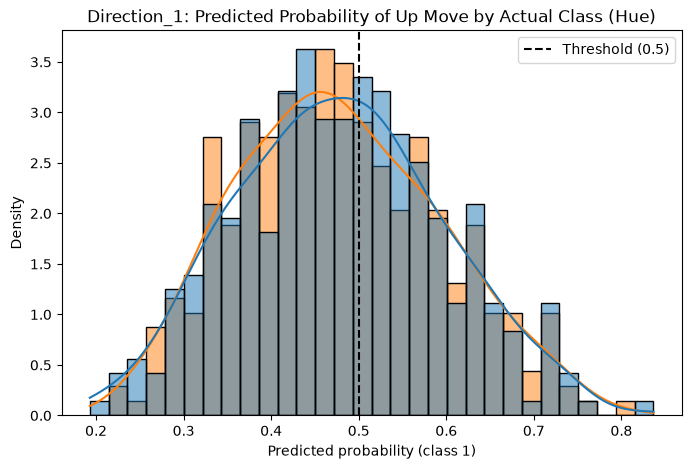

In [ ]:
numeric_features = X_1.columns # All of the features are numeric but we will make the distinction for transparency

preprocessor_1 = ColumnTransformer([
    ("numeric", "passthrough", numeric_features) # XGB is DT based. No scaling needed
])

xgb_1 = XGBClassifier(objective="binary:logistic",eval_metric="logloss",n_estimators=300,
    max_depth=3,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,reg_lambda=1.0,
    random_state=13,n_jobs=-1,tree_method="hist"
)

pipeline_1 = Pipeline([
    ("preprocessor", preprocessor_1),
    ("classifier", xgb_1)
])

print(pipeline_1.named_steps)

pipeline_1.fit(X_train_1, y_train_1)

y_pred_1 = pipeline_1.predict(X_test_1)
p_up_1 = pipeline_1.predict_proba(X_test_1)[:,1] #Probabilities

print(classification_report(y_test_1, y_pred_1))
print(f"ROC-AUC: {roc_auc_score(y_test_1, p_up_1):.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(x=p_up_1,hue=y_test_1.rename("Actual class"),bins=30,kde=True,stat="density",common_norm=False,ax=ax,)
plt.axvline(0.5, color="k", linestyle="--", label="Threshold (0.5)")
plt.title("Direction_1: Predicted Probability of Up Move by Actual Class (Hue)")
plt.xlabel("Predicted probability (class 1)")
plt.legend()
plt.show()


Not amazing but compared to the equivalent baseline LR model it's slightly better at spotting both classes.

Let's hypertune:

In [15]:
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Best parameters: {'classifier__colsample_bytree': np.float64(0.8320953338437802), 'classifier__gamma': np.float64(3.1461990790014123), 'classifier__learning_rate': np.float64(0.10364778864746883), 'classifier__max_depth': 2, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 378, 'classifier__reg_alpha': np.float64(1.3848425962226925), 'classifier__reg_lambda': np.float64(30.893003548012544), 'classifier__subsample': np.float64(0.6341498232195536)}
Best CV ROC-AUC: 0.5310
              precision    recall  f1-score   support

           0       0.49      0.54      0.51       334
           1       0.46      0.41      0.43       321

    accuracy                           0.48       655
   macro avg       0.47      0.48      0.47       655
weighted avg       0.47      0.48      0.47       655

Test ROC-AUC: 0.4867
     mean_train_roc_auc  mean_test_roc_auc  std_test_roc_auc  \
116            0.629615           0

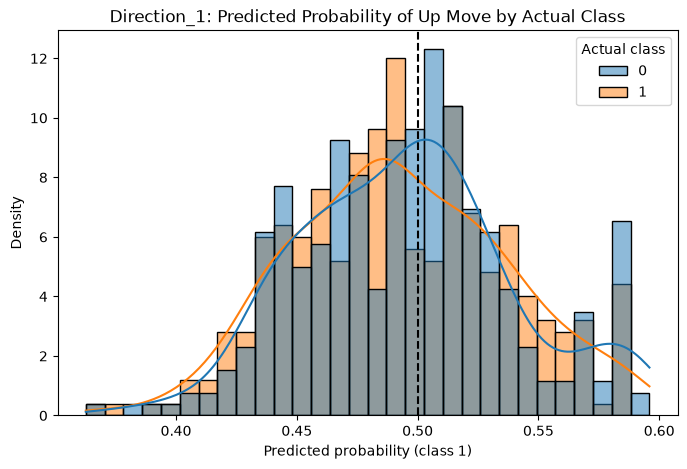

In [19]:
numeric_features = X_1.columns  # All numeric features

preprocessor_1 = ColumnTransformer([
    ("numeric", "passthrough", numeric_features)
])

xgb_1 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=13,
    n_jobs=1,  # Avoid nested parallelism
    tree_method="hist"
)

pipeline_1 = Pipeline([
    ("preprocessor", preprocessor_1),
    ("classifier", xgb_1)
])

param_distributions_1 = {
    "classifier__n_estimators": randint(100, 801),
    "classifier__max_depth": randint(2, 7),
    "classifier__learning_rate": loguniform(0.01, 0.2),
    "classifier__subsample": uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 11),
    "classifier__gamma": uniform(0, 5),
    "classifier__reg_alpha": loguniform(1e-4, 10),
    "classifier__reg_lambda": loguniform(0.1, 100)
}

cv_1 = TimeSeriesSplit(n_splits=5,gap=1)  # Adjust based on target prediction horizon)

random_search_1 = RandomizedSearchCV(
    estimator=pipeline_1,
    param_distributions=param_distributions_1,
    n_iter=500,
    scoring={
        "roc_auc": "roc_auc",
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="roc_auc",
    cv=cv_1,
    n_jobs=-1,
    random_state=13,
    verbose=1,
    return_train_score=True,
    error_score="raise"
)

random_search_1.fit(X_train_1, y_train_1)

pipeline_1 = random_search_1.best_estimator_

print("Best parameters:", random_search_1.best_params_)
print(f"Best CV ROC-AUC: {random_search_1.best_score_:.4f}")

y_pred_1 = pipeline_1.predict(X_test_1)
p_up_1 = pipeline_1.predict_proba(X_test_1)[:, 1]
print(classification_report(y_test_1, y_pred_1))
print(f"Test ROC-AUC: {roc_auc_score(y_test_1, p_up_1):.4f}")
results_1 = pd.DataFrame(random_search_1.cv_results_)

print(
    results_1[
        [
            "mean_train_roc_auc",
            "mean_test_roc_auc",
            "std_test_roc_auc",
            "mean_test_accuracy",
            "mean_test_f1"
        ]
    ]
    .sort_values("mean_test_roc_auc", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    x=p_up_1,
    hue=y_test_1.rename("Actual class"),
    bins=30,
    kde=True,
    stat="density",
    common_norm=False,
    ax=ax
)

ax.axvline(0.5, color="k", linestyle="--", label="Threshold (0.5)")
ax.set_title("Direction_1: Predicted Probability of Up Move by Actual Class")
ax.set_xlabel("Predicted probability (class 1)")
plt.show()

Still quite poor performance. Is this due to the data or the model? Let's go straight to hp-tunining on the longer timeframe datasets:

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Best parameters: {'classifier__colsample_bytree': np.float64(0.7166280808646814), 'classifier__gamma': np.float64(2.489881146857435), 'classifier__learning_rate': np.float64(0.05559494642589484), 'classifier__max_depth': 4, 'classifier__min_child_weight': 2, 'classifier__n_estimators': 753, 'classifier__reg_alpha': np.float64(8.17474635898718), 'classifier__reg_lambda': np.float64(23.288352110823002), 'classifier__subsample': np.float64(0.8783171231471536)}
Best CV ROC-AUC: 0.5347
              precision    recall  f1-score   support

         0.0       0.47      0.37      0.42       331
         1.0       0.47      0.57      0.52       323

    accuracy                           0.47       654
   macro avg       0.47      0.47      0.47       654
weighted avg       0.47      0.47      0.47       654

Test ROC-AUC: 0.4790
     mean_train_roc_auc  mean_test_roc_auc  std_test_roc_auc  \
146            0.703477           0.53

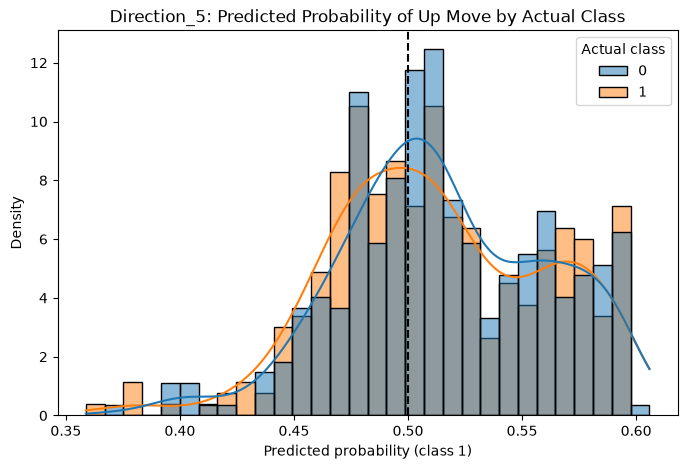

In [20]:
numeric_features = X_5.columns  # All numeric features

preprocessor_5 = ColumnTransformer([
    ("numeric", "passthrough", numeric_features)
])

xgb_5 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=13,
    n_jobs=1,  # Avoid nested parallelism
    tree_method="hist"
)

pipeline_5 = Pipeline([
    ("preprocessor", preprocessor_5),
    ("classifier", xgb_5)
])

param_distributions_5 = {
    "classifier__n_estimators": randint(100, 801),
    "classifier__max_depth": randint(2, 7),
    "classifier__learning_rate": loguniform(0.01, 0.2),
    "classifier__subsample": uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 11),
    "classifier__gamma": uniform(0, 5),
    "classifier__reg_alpha": loguniform(1e-4, 10),
    "classifier__reg_lambda": loguniform(0.1, 100)
}

cv_5 = TimeSeriesSplit(n_splits=5,gap=1)  # Adjust based on target prediction horizon)

random_search_5 = RandomizedSearchCV(
    estimator=pipeline_5,
    param_distributions=param_distributions_5,
    n_iter=500,
    scoring={
        "roc_auc": "roc_auc",
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="roc_auc",
    cv=cv_5,
    n_jobs=-1,
    random_state=13,
    verbose=1,
    return_train_score=True,
    error_score="raise"
)

random_search_5.fit(X_train_5, y_train_5)

pipeline_5 = random_search_5.best_estimator_

print("Best parameters:", random_search_5.best_params_)
print(f"Best CV ROC-AUC: {random_search_5.best_score_:.4f}")

y_pred_5 = pipeline_5.predict(X_test_5)
p_up_5 = pipeline_5.predict_proba(X_test_5)[:, 1]
print(classification_report(y_test_5, y_pred_5))
print(f"Test ROC-AUC: {roc_auc_score(y_test_5, p_up_5):.4f}")
results_5 = pd.DataFrame(random_search_5.cv_results_)

print(
    results_5[
        [
            "mean_train_roc_auc",
            "mean_test_roc_auc",
            "std_test_roc_auc",
            "mean_test_accuracy",
            "mean_test_f1"
        ]
    ]
    .sort_values("mean_test_roc_auc", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    x=p_up_5,
    hue=y_test_5.rename("Actual class"),
    bins=30,
    kde=True,
    stat="density",
    common_norm=False,
    ax=ax
)

ax.axvline(0.5, color="k", linestyle="--", label="Threshold (0.5)")
ax.set_title("Direction_5: Predicted Probability of Up Move by Actual Class")
ax.set_xlabel("Predicted probability (class 1)")
plt.show()

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Best parameters: {'classifier__colsample_bytree': np.float64(0.9084592540088507), 'classifier__gamma': np.float64(4.846662583691358), 'classifier__learning_rate': np.float64(0.010154980717814462), 'classifier__max_depth': 3, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 121, 'classifier__reg_alpha': np.float64(0.040867284104500266), 'classifier__reg_lambda': np.float64(81.45635568084735), 'classifier__subsample': np.float64(0.6123496570567368)}
Best CV ROC-AUC: 0.5436
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       328
         1.0       0.50      1.00      0.67       326

    accuracy                           0.50       654
   macro avg       0.25      0.50      0.33       654
weighted avg       0.25      0.50      0.33       654

Test ROC-AUC: 0.4792
     mean_train_roc_auc  mean_test_roc_auc  std_test_roc_auc  \
73             0.688469           

c:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


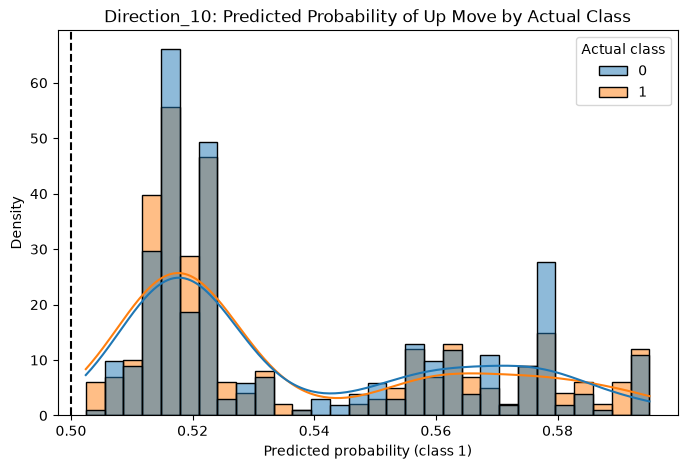

In [21]:
numeric_features = X_10.columns  # All numeric features

preprocessor_10 = ColumnTransformer([
    ("numeric", "passthrough", numeric_features)
])

xgb_10 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=13,
    n_jobs=1,  # Avoid nested parallelism
    tree_method="hist"
)

pipeline_10 = Pipeline([
    ("preprocessor", preprocessor_10),
    ("classifier", xgb_10)
])

param_distributions_10 = {
    "classifier__n_estimators": randint(100, 801),
    "classifier__max_depth": randint(2, 7),
    "classifier__learning_rate": loguniform(0.01, 0.2),
    "classifier__subsample": uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 11),
    "classifier__gamma": uniform(0, 5),
    "classifier__reg_alpha": loguniform(1e-4, 10),
    "classifier__reg_lambda": loguniform(0.1, 100)
}

cv_10 = TimeSeriesSplit(n_splits=5,gap=1)  # Adjust based on target prediction horizon)

random_search_10 = RandomizedSearchCV(
    estimator=pipeline_10,
    param_distributions=param_distributions_10,
    n_iter=500,
    scoring={
        "roc_auc": "roc_auc",
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="roc_auc",
    cv=cv_10,
    n_jobs=-1,
    random_state=13,
    verbose=1,
    return_train_score=True,
    error_score="raise"
)

random_search_10.fit(X_train_10, y_train_10)

pipeline_10 = random_search_10.best_estimator_

print("Best parameters:", random_search_10.best_params_)
print(f"Best CV ROC-AUC: {random_search_10.best_score_:.4f}")

y_pred_10 = pipeline_10.predict(X_test_10)
p_up_10 = pipeline_10.predict_proba(X_test_10)[:, 1]
print(classification_report(y_test_10, y_pred_10))
print(f"Test ROC-AUC: {roc_auc_score(y_test_10, p_up_10):.4f}")
results_10 = pd.DataFrame(random_search_10.cv_results_)

print(
    results_10[
        [
            "mean_train_roc_auc",
            "mean_test_roc_auc",
            "std_test_roc_auc",
            "mean_test_accuracy",
            "mean_test_f1"
        ]
    ]
    .sort_values("mean_test_roc_auc", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    x=p_up_10,
    hue=y_test_10.rename("Actual class"),
    bins=30,
    kde=True,
    stat="density",
    common_norm=False,
    ax=ax
)

ax.axvline(0.5, color="k", linestyle="--", label="Threshold (0.5)")
ax.set_title("Direction_10: Predicted Probability of Up Move by Actual Class")
ax.set_xlabel("Predicted probability (class 1)")
plt.show()

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Best parameters: {'classifier__colsample_bytree': np.float64(0.6846643691550823), 'classifier__gamma': np.float64(4.839508132190799), 'classifier__learning_rate': np.float64(0.023510995902726983), 'classifier__max_depth': 6, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 143, 'classifier__reg_alpha': np.float64(0.004011378501696497), 'classifier__reg_lambda': np.float64(0.3798013884432246), 'classifier__subsample': np.float64(0.9073806114076362)}
Best CV ROC-AUC: 0.5424
              precision    recall  f1-score   support

         0.0       0.53      0.77      0.63       348
         1.0       0.46      0.22      0.29       304

    accuracy                           0.51       652
   macro avg       0.49      0.50      0.46       652
weighted avg       0.50      0.51      0.47       652

Test ROC-AUC: 0.5053
     mean_train_roc_auc  mean_test_roc_auc  std_test_roc_auc  \
219            0.954899          

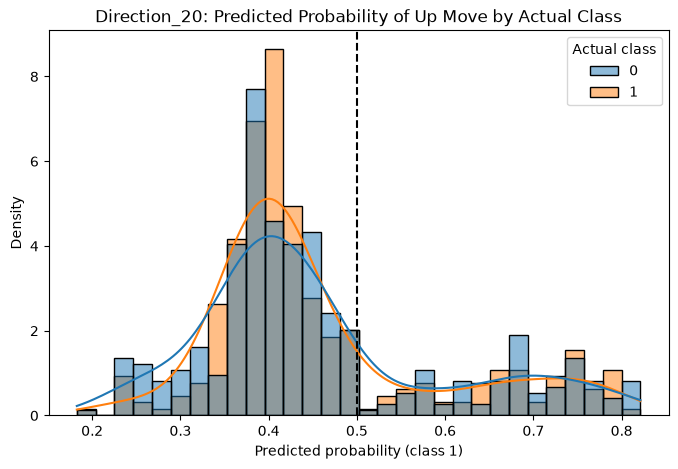

In [22]:
numeric_features = X_20.columns  # All numeric features

preprocessor_20 = ColumnTransformer([
    ("numeric", "passthrough", numeric_features)
])

xgb_20 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=13,
    n_jobs=1,  # Avoid nested parallelism
    tree_method="hist"
)

pipeline_20 = Pipeline([
    ("preprocessor", preprocessor_20),
    ("classifier", xgb_20)
])

param_distributions_20 = {
    "classifier__n_estimators": randint(100, 801),
    "classifier__max_depth": randint(2, 7),
    "classifier__learning_rate": loguniform(0.01, 0.2),
    "classifier__subsample": uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 11),
    "classifier__gamma": uniform(0, 5),
    "classifier__reg_alpha": loguniform(1e-4, 10),
    "classifier__reg_lambda": loguniform(0.1, 100)
}

cv_20 = TimeSeriesSplit(n_splits=5,gap=1)  # Adjust based on target prediction horizon)

random_search_20 = RandomizedSearchCV(
    estimator=pipeline_20,
    param_distributions=param_distributions_20,
    n_iter=500,
    scoring={
        "roc_auc": "roc_auc",
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="roc_auc",
    cv=cv_20,
    n_jobs=-1,
    random_state=13,
    verbose=1,
    return_train_score=True,
    error_score="raise"
)

random_search_20.fit(X_train_20, y_train_20)

pipeline_20 = random_search_20.best_estimator_

print("Best parameters:", random_search_20.best_params_)
print(f"Best CV ROC-AUC: {random_search_20.best_score_:.4f}")

y_pred_20 = pipeline_20.predict(X_test_20)
p_up_20 = pipeline_20.predict_proba(X_test_20)[:, 1]
print(classification_report(y_test_20, y_pred_20))
print(f"Test ROC-AUC: {roc_auc_score(y_test_20, p_up_20):.4f}")
results_20 = pd.DataFrame(random_search_20.cv_results_)

print(
    results_20[
        [
            "mean_train_roc_auc",
            "mean_test_roc_auc",
            "std_test_roc_auc",
            "mean_test_accuracy",
            "mean_test_f1"
        ]
    ]
    .sort_values("mean_test_roc_auc", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    x=p_up_20,
    hue=y_test_20.rename("Actual class"),
    bins=30,
    kde=True,
    stat="density",
    common_norm=False,
    ax=ax
)

ax.axvline(0.5, color="k", linestyle="--", label="Threshold (0.5)")
ax.set_title("Direction_20: Predicted Probability of Up Move by Actual Class")
ax.set_xlabel("Predicted probability (class 1)")
plt.show()

Go back and mess with the hyperparameters for each timeframe to extract performance.